# Anomaly Detection and Unsupervised Learning

**You can never collect data on a failure that has not happened yet — so instead of learning what failure looks like, you learn what *normal* looks like, and watch for anything that isn't.**

*Companion notebook to Chapter 56 — Anomaly Detection and Unsupervised Learning.*

Supervised learning requires labeled examples of failures. In structural health monitoring, failures are rare — that is the whole point of designing safe structures — so labeled failure data is almost never available in sufficient quantity for supervised training. *Anomaly detection* sidesteps this problem by learning only from normal data: it builds a model of what the structure looks and sounds like when healthy, then flags departures from that model as anomalies worth investigating.

Two complementary approaches are demonstrated here. **The PCA Q statistic** (squared reconstruction error) compresses the multi-channel feature vector into a low-dimensional representation of normal variation, then measures how far each new sample lies from that normal subspace. Samples that cannot be reconstructed accurately — because their pattern does not match anything seen during normal operation — are flagged as anomalies. This approach is interpretable: the reconstruction error has physical meaning as "how abnormal is this sample compared to the training distribution."

**Isolation Forest** takes a fundamentally different approach, exploiting the geometric intuition that anomalies are rare and structurally different from normal points, and therefore easier to isolate in feature space. It builds an ensemble of random decision trees that recursively partition the feature space; anomalies require fewer partitions to isolate and receive correspondingly extreme anomaly scores. The key tuning parameter is the contamination fraction; because we fit the forest on the healthy baseline alone, it sets the share of that baseline the model will flag — in effect, the tolerated false-alarm rate — and thereby fixes the decision threshold.

**This notebook demonstrates:**
1. Anomaly detection on a four-channel strain feature dataset using the PCA Q statistic (threshold at the 99th percentile of held-out normal scores, checked against the Jackson–Mudholkar limit) and Isolation Forest, comparing detection rate and false alarms — with all preprocessing statistics learned from the healthy baseline alone, so no anomaly information leaks into the model.

In [1]:
# Colab setup: uncomment to install dependencies when running in Google Colab
# !pip install numpy matplotlib scikit-learn

import pathlib

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from scipy.stats import norm
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

%matplotlib inline
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11, 'axes.titlesize': 12})

---
## 1 — PCA Q Statistic and Isolation Forest: Detecting Load-Path Changes

The simulation creates 1000 normal operating samples (zero-mean, unit covariance in four feature dimensions) and 30 anomalous samples whose mean is shifted to [2, 2, −2, −2] and whose spread is wider than normal — representing a load-path change that elevates two feature channels while suppressing two others, as might occur if a structural member buckles or a joint fails. A further 2000 normal samples are generated as an untouched holdout. The challenge is to detect the 30 anomalies without prior knowledge of what they look like.

The normal record is split in time, following the chapter's threshold procedure. The first 600 samples fit the `StandardScaler` and the two-component PCA (preprocessing statistics from the healthy baseline only, so no anomaly information leaks in). The next 400 are a calibration set the model never saw; the alarm threshold is the 99th percentile of their Q values (Q = ‖x − x̂‖², the squared distance from the retained subspace). The 2000-sample holdout then measures the false-alarm rate the threshold actually delivers.

Why a quantile and not mean + 3σ? Q is a sum of squared residuals, non-negative and right-skewed, so a 3σ rule does not deliver the 0.3% false-alarm rate it would for Gaussian data; the cell prints the realized rate for comparison. The analytic alternative, the Jackson–Mudholkar (1979) limit computed from the discarded eigenvalues, is printed beside the empirical quantile.

The left panel shows the PCA score space (scores on the two retained components). Some anomalies lie well outside the normal cloud there; many do not, because what distinguishes them is variance *off* the retained plane, which this projection cannot show. The right panel shows that off-plane distance, Q, over time: the anomalies with large Q stand out above the threshold.

Q threshold (99th percentile of calibration Q) = 9.482
Jackson-Mudholkar 99% limit                     = 8.924
(mean + 3 sigma of calibration Q would be       = 8.826; holdout false-alarm rate 1.85% vs 0.3% nominal)
Detected 22/30 anomalies; false-alarm rate on 2000 holdout normal samples = 1.45% (design 1%)
Isolation Forest: detected 23/30; holdout false-alarm rate 3.90%


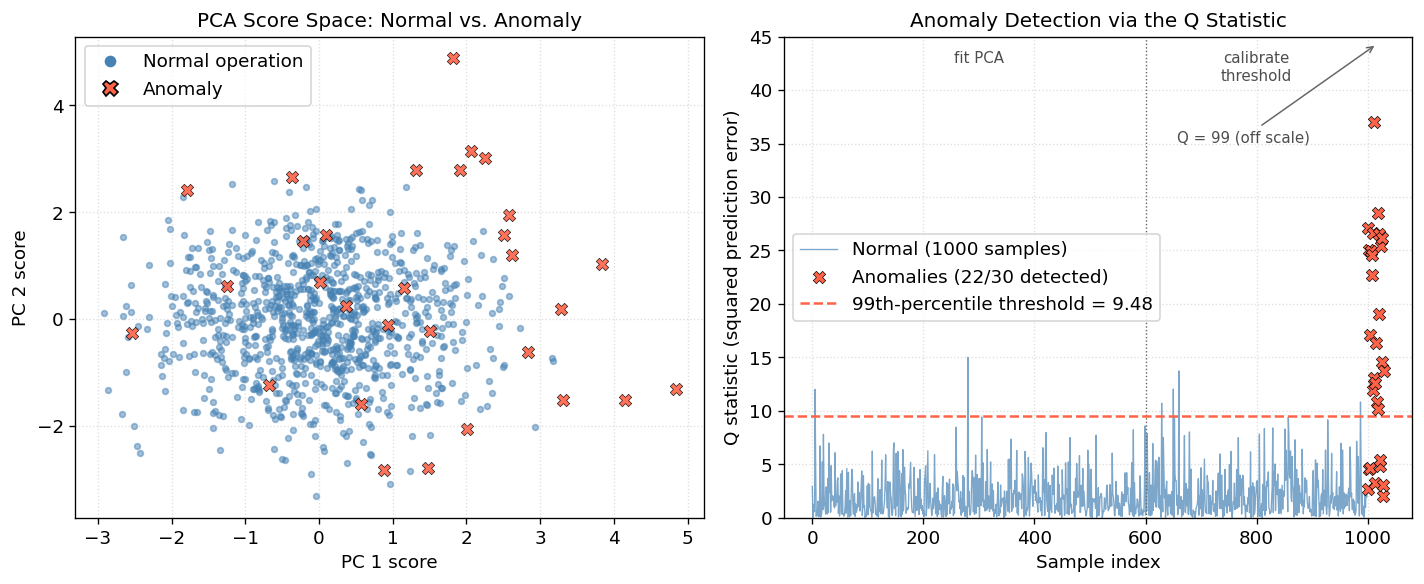

Figure saved to ..\src\media\ch56\fig56_2_anomaly_detection.png


In [2]:
# --- Reproducibility and experiment configuration -------------------------
SEED = 10                        # seeds every source of randomness below
N_NORMAL = 1000                  # healthy-baseline record shown in the figure
N_TRAIN = 600                    # first part of that record: fits the scaler and PCA
N_HOLDOUT = 2000                 # further normal data, used only to check the false-alarm rate
N_ANOM = 30                      # injected anomalies (a load-path change)
N_FEATURES = 4                   # strain feature channels
ANOMALY_MEAN = [2, 2, -2, -2]    # mean shift of the anomalous samples
ANOMALY_COV_SCALE = 3            # anomalies are more dispersed than normal
N_COMPONENTS = 2                 # PCA components retained for the normal subspace
QUANTILE = 0.99                  # threshold = 99th percentile of calibration Q (1% design FAR)
CONTAMINATION = N_ANOM / (N_NORMAL + N_ANOM)  # expected outlier fraction for the forest

OUT_DIR = pathlib.Path('../src/media/ch56')
OUT_DIR.mkdir(parents=True, exist_ok=True)


def q_statistic(model, X):
    """Return the per-sample Q statistic (squared prediction error, SPE).

    Each row of ``X`` is projected onto the retained principal-component
    subspace and reconstructed; Q is the squared distance between a sample and
    its reconstruction, Q = ||x - x_hat||^2, as defined in the chapter. Large
    values mean the sample lies far from the normal subspace learned in fitting.
    """
    X_recon = model.inverse_transform(model.transform(X))
    return np.sum((X - X_recon) ** 2, axis=1)


def jackson_mudholkar_limit(discarded_eigenvalues, alpha):
    """Jackson-Mudholkar (1979) upper control limit for Q at false-alarm rate alpha."""
    lam = np.asarray(discarded_eigenvalues)
    t1, t2, t3 = lam.sum(), (lam ** 2).sum(), (lam ** 3).sum()
    h0 = 1.0 - 2.0 * t1 * t3 / (3.0 * t2 ** 2)
    c = norm.ppf(1.0 - alpha)
    return t1 * (c * np.sqrt(2.0 * t2 * h0 ** 2) / t1 + 1.0
                 + t2 * h0 * (h0 - 1.0) / t1 ** 2) ** (1.0 / h0)


# --- Synthetic four-channel strain data -----------------------------------
np.random.seed(SEED)
X_normal = np.random.multivariate_normal(
    np.zeros(N_FEATURES), np.eye(N_FEATURES), N_NORMAL)
X_anom = np.random.multivariate_normal(
    ANOMALY_MEAN, np.eye(N_FEATURES) * ANOMALY_COV_SCALE, N_ANOM)
X_holdout = np.random.multivariate_normal(
    np.zeros(N_FEATURES), np.eye(N_FEATURES), N_HOLDOUT)
X_all = np.vstack([X_normal, X_anom])
labels = np.array(['OK'] * N_NORMAL + ['Anomaly'] * N_ANOM)

# Fit the scaler and PCA on the TRAINING part of the healthy baseline only, then
# apply the same transform to every sample. Fitting on the full set would let the
# anomalies leak into the centering/scaling statistics.
X_train = X_normal[:N_TRAIN]
scaler = StandardScaler().fit(X_train)
Xs = scaler.transform(X_all)
Xs_train = Xs[:N_TRAIN]
Xs_holdout = scaler.transform(X_holdout)

# --- PCA Q statistic -------------------------------------------------------
pca = PCA(n_components=N_COMPONENTS).fit(Xs_train)
Q = q_statistic(pca, Xs)
Q_cal = Q[N_TRAIN:N_NORMAL]              # calibration: normal data not used in fitting
Q_holdout = q_statistic(pca, Xs_holdout)

# Q is a sum of squares: non-negative and right-skewed, so a mean + 3 sigma rule
# does not deliver its nominal 0.3% false-alarm rate. Set the threshold at an
# empirical quantile of held-out normal scores instead (the chapter's procedure).
threshold = np.quantile(Q_cal, QUANTILE)
naive_3sigma = Q_cal.mean() + 3 * Q_cal.std()

# The analytic alternative: the Jackson-Mudholkar limit from the discarded eigenvalues.
full_pca = PCA().fit(Xs_train)
jm = jackson_mudholkar_limit(full_pca.explained_variance_[N_COMPONENTS:], 1 - QUANTILE)

detected = np.sum(Q[N_NORMAL:] > threshold)
far_holdout = np.mean(Q_holdout > threshold)
far_3sigma = np.mean(Q_holdout > naive_3sigma)
print(f"Q threshold (99th percentile of calibration Q) = {threshold:.3f}")
print(f"Jackson-Mudholkar 99% limit                     = {jm:.3f}")
print(f"(mean + 3 sigma of calibration Q would be       = {naive_3sigma:.3f};"
      f" holdout false-alarm rate {100 * far_3sigma:.2f}% vs 0.3% nominal)")
print(f"Detected {detected}/{N_ANOM} anomalies; false-alarm rate on "
      f"{N_HOLDOUT} holdout normal samples = {100 * far_holdout:.2f}% (design 1%)")

# --- Isolation Forest (fit on the training baseline only) -----------------
iso = IsolationForest(contamination=CONTAMINATION, random_state=SEED).fit(Xs_train)
iso_detected = np.sum(iso.predict(Xs[N_NORMAL:]) == -1)
iso_far = np.mean(iso.predict(Xs_holdout) == -1)
print(f"Isolation Forest: detected {iso_detected}/{N_ANOM}; "
      f"holdout false-alarm rate {100 * iso_far:.2f}%")

# --- Figure ---------------------------------------------------------------
idx = np.arange(len(X_all))
scores = pca.transform(Xs)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left panel: PCA score space. A distinct MARKER per class (not colour alone)
# keeps the two groups separable in grayscale / B&W print.
ok = labels == 'OK'
axes[0].scatter(scores[ok, 0], scores[ok, 1], marker='o', s=12, alpha=0.5,
                color='steelblue', label='Normal operation')
axes[0].scatter(scores[~ok, 0], scores[~ok, 1], marker='X', s=55, alpha=0.9,
                color='tomato', edgecolor='black', linewidths=0.4, label='Anomaly')
axes[0].set_title('PCA Score Space: Normal vs. Anomaly')
axes[0].set_xlabel('PC 1 score')
axes[0].set_ylabel('PC 2 score')
axes[0].grid(True, linestyle=':', alpha=0.4)
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='steelblue',
           markersize=8, label='Normal operation'),
    Line2D([0], [0], marker='X', color='w', markerfacecolor='tomato',
           markeredgecolor='black', markersize=9, label='Anomaly')]
axes[0].legend(handles=legend_elements, loc='upper left')

# Right panel: Q statistic over time
axes[1].plot(idx[:N_NORMAL], Q[:N_NORMAL], color='steelblue', lw=0.8,
             alpha=0.7, label=f'Normal ({N_NORMAL} samples)')
axes[1].axvline(N_TRAIN, color='0.4', lw=0.8, linestyle=':')
axes[1].text(N_TRAIN / 2, 0.97, 'fit PCA', transform=axes[1].get_xaxis_transform(),
             ha='center', va='top', fontsize=9, color='0.3')
axes[1].text((N_TRAIN + N_NORMAL) / 2, 0.97, 'calibrate\nthreshold',
             transform=axes[1].get_xaxis_transform(), ha='center', va='top',
             fontsize=9, color='0.3')
# Same X marker as the left panel: shape, not color, names the anomalies.
axes[1].scatter(idx[N_NORMAL:], Q[N_NORMAL:], color='tomato', marker='X',
                s=55, edgecolor='black', linewidths=0.4, zorder=5,
                label=f'Anomalies ({detected}/{N_ANOM} detected)')
axes[1].axhline(threshold, color='tomato', lw=1.5, linestyle='--',
                label=f'99th-percentile threshold = {threshold:.2f}')
# Clip the y-axis so the threshold region stays legible; mark any off-scale point.
Y_TOP = 45.0
axes[1].set_ylim(0, Y_TOP)
for i in idx[N_NORMAL:][Q[N_NORMAL:] > Y_TOP]:
    axes[1].annotate(f'Q = {Q[i]:.0f} (off scale)', xy=(i, Y_TOP * 0.985),
                     xytext=(i - 360, Y_TOP * 0.78), fontsize=9, color='0.3',
                     arrowprops=dict(arrowstyle='->', color='0.4', lw=0.9))
axes[1].set_xlabel('Sample index')
axes[1].set_ylabel('Q statistic (squared prediction error)')
axes[1].set_title('Anomaly Detection via the Q Statistic')
axes[1].legend(loc='center left')
axes[1].grid(True, linestyle=':', alpha=0.4)

plt.tight_layout()
plt.savefig(OUT_DIR / 'fig56_2_anomaly_detection.png', bbox_inches='tight', dpi=300)
plt.show()
print(f"Figure saved to {OUT_DIR / 'fig56_2_anomaly_detection.png'}")

---
## Where to take this next

The demonstration above is a foundation. Three concrete extensions turn it into something closer to a deployable monitor:

1. **Validate the threshold out of sample.** The holdout here is drawn from the same distribution as the training data. In a real record, separate it by time, season, or operating condition and measure the realized false-alarm rate there. Compare it against the design target — an in-sample estimate almost always looks better than the field will.

2. **Compare the threshold rules.** Plot the histogram of calibration Q values and mark the 99th percentile, the Jackson–Mudholkar limit, and mean + 3σ. Vary `N_TRAIN` and the calibration size and watch how stable each threshold is, and how far the 3σ rule's realized false-alarm rate sits from its nominal 0.3%.

3. **Add temporal and nonlinear structure.** Layer a CUSUM statistic (Eq. 56.2) on top of the per-sample Q statistic to catch a slow drift whose individual samples never trip the point threshold — the fatigue-progression case the chapter highlights. Then swap the linear PCA model for a small autoencoder (Eq. 56.1) and check whether the nonlinear normal manifold separates the same anomalies with a lower false-alarm rate.